In [1]:
#import bert_score
#from deepeval.metrics import GEval
#from deepeval.test_case import LLMTestCase, LLMTestCaseParams
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
import pprint
from sklearn import metrics
import urllib

#from deepeval.models import AmazonBedrockModel

#import boto3
from pydantic_ai.models.bedrock import BedrockConverseModel
from pydantic_evals import Dataset, Case
from pydantic_evals.evaluators import LLMJudge
from pydantic_ai.settings import ModelSettings

import asyncio
import concurrent.futures

#from ragas.metrics import AnswerCorrectness 
#from ragas import EvaluationDataset, evaluate as ragas_evaluate
#from langchain_aws import ChatBedrockConverse, BedrockEmbeddings
#from ragas.llms import LangchainLLMWrapper
#from ragas.embeddings import LangchainEmbeddingsWrapper

import nest_asyncio
nest_asyncio.apply()

In [2]:
normalise_threshold=True

In [3]:
settings={}
settings["n_prompts"] = 30
settings["region"] = "eu-west-2"
settings["temperature"] = 0
settings["threshold"] = 0.5

In [4]:
models = {}

#models['Claude 3 Haiku'] = 'anthropic.claude-3-haiku-20240307-v1:0'
models['Claude 3.7 Sonnet'] = 'anthropic.claude-3-7-sonnet-20250219-v1:0'
#models['GPT OSS 20b'] = "openai.gpt-oss-20b-1:0"
models['GPT OSS 120b'] = "openai.gpt-oss-120b-1:0"

## Set Environment Variables

In [5]:
os.environ["AWS_DEFAULT_REGION"] = settings["region"]

## Get Data

In [6]:
datasets = [
    'https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/dialogue_data.json',
    'https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/general_data.json',
    'https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/qa_data.json',
    'https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/summarization_data.json'
   ]

In [7]:
for directory in ['data', 'output']:
    if not os.path.exists(directory):
        os.makedirs(directory)
    
for dataset in datasets:
    print(dataset)
    filename=dataset.split('/')[-1]
    if not os.path.isfile(f'data/{filename}'):
        print(f'downloading {filename}')
        urllib.request.urlretrieve(dataset, f'data/{filename}')

https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/dialogue_data.json
https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/general_data.json
https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/qa_data.json
https://raw.githubusercontent.com/RUCAIBox/HaluEval/main/data/summarization_data.json


## Q and A

In [8]:
qa_df = pd.read_json("data/qa_data.json", lines=True)
qa_df

,knowledge,question,right_answer,hallucinated_answer
0,Arthur's Magazine (1844–1846) was an American ...,Which magazine was started first Arthur's Maga...,Arthur's Magazine,First for Women was started first.
1,The Oberoi family is an Indian family that is ...,The Oberoi family is part of a hotel company t...,Delhi,The Oberoi family's hotel company is based in ...
2,"Allison Beth ""Allie"" Goertz (born March 2, 199...",Musician and satirist Allie Goertz wrote a son...,President Richard Nixon,"Allie Goertz wrote a song about Milhouse, a po..."
3,"Margaret ""Peggy"" Seeger (born June 17, 1935) i...",What nationality was James Henry Miller's wife?,American,James Henry Miller's wife was British.
4,It is a hygroscopic solid that is highly solu...,Cadmium Chloride is slightly soluble in this c...,alcohol,water with a hint of alcohol
...,...,...,...,...
9995,James Norman Hall (22 April 1887 – 5 July 1951...,Are James Norman Hall and Amiri Baraka from th...,yes,James Norman Hall was French.
9996,Love in the Time of Money is a 2002 American r...,The actress who appeared in the 2002 film Love...,1979,The actress who appeared in the 2002 film Love...
9997,"Ape Escape, known in Japan as Excited Saru Get...",how is Ape Escape and Nicktoons Film Festival ...,shorts,Ape Escape and Nicktoons Film Festival are con...
9998,"An accomplished full-forward, Capper kicked 3...",What position did both Warwick Capper and John...,full forward,Warwick Capper played midfield.


In [9]:
qa_not_hallucination_df = qa_df.copy()
qa_not_hallucination_df['answer'] = qa_not_hallucination_df['right_answer']
qa_not_hallucination_df['is_hallucination'] = False

qa_hallucination_df = qa_df.copy()
qa_hallucination_df['answer'] = qa_hallucination_df['hallucinated_answer']
qa_hallucination_df['is_hallucination'] = True

qa_answers_df = pd.concat([qa_not_hallucination_df, qa_hallucination_df])
qa_answers_df.reset_index(drop=True)
qa_answers_df

,knowledge,question,right_answer,hallucinated_answer,answer,is_hallucination
0,Arthur's Magazine (1844–1846) was an American ...,Which magazine was started first Arthur's Maga...,Arthur's Magazine,First for Women was started first.,Arthur's Magazine,False
1,The Oberoi family is an Indian family that is ...,The Oberoi family is part of a hotel company t...,Delhi,The Oberoi family's hotel company is based in ...,Delhi,False
2,"Allison Beth ""Allie"" Goertz (born March 2, 199...",Musician and satirist Allie Goertz wrote a son...,President Richard Nixon,"Allie Goertz wrote a song about Milhouse, a po...",President Richard Nixon,False
3,"Margaret ""Peggy"" Seeger (born June 17, 1935) i...",What nationality was James Henry Miller's wife?,American,James Henry Miller's wife was British.,American,False
4,It is a hygroscopic solid that is highly solu...,Cadmium Chloride is slightly soluble in this c...,alcohol,water with a hint of alcohol,alcohol,False
...,...,...,...,...,...,...
9995,James Norman Hall (22 April 1887 – 5 July 1951...,Are James Norman Hall and Amiri Baraka from th...,yes,James Norman Hall was French.,James Norman Hall was French.,True
9996,Love in the Time of Money is a 2002 American r...,The actress who appeared in the 2002 film Love...,1979,The actress who appeared in the 2002 film Love...,The actress who appeared in the 2002 film Love...,True
9997,"Ape Escape, known in Japan as Excited Saru Get...",how is Ape Escape and Nicktoons Film Festival ...,shorts,Ape Escape and Nicktoons Film Festival are con...,Ape Escape and Nicktoons Film Festival are con...,True
9998,"An accomplished full-forward, Capper kicked 3...",What position did both Warwick Capper and John...,full forward,Warwick Capper played midfield.,Warwick Capper played midfield.,True


In [10]:
def evaluate_pydantic(knowledge: str, question: str, answer: str, settings: dict) -> dict:
    judge = LLMJudge(
        model=BedrockConverseModel(settings["model_id"]),
        rubric=settings["rubric"],
        score={'evaluation_name': 'HallucinationScore'},
        model_settings=ModelSettings(
            temperature=settings["temperature"],
            max_tokens=2048,
        ),
        include_input=True,
        include_expected_output=True,
    )

    dataset = Dataset(
        cases=[Case(inputs=question, expected_output=knowledge)],
        evaluators=[judge],
    )

    def run_in_thread():
        loop = asyncio.new_event_loop()
        asyncio.set_event_loop(loop)
        try:
            return loop.run_until_complete(dataset.evaluate(lambda x: answer))
        finally:
            loop.close()

    with concurrent.futures.ThreadPoolExecutor(max_workers=1) as executor:
        report = executor.submit(run_in_thread).result()

    case_result = report.cases[0]
    score = 1 - case_result.scores['HallucinationScore'].value
    threshold = settings.get("threshold", 0.5)

    return {
        'method': 'Pydantic',
        'score': score,
        'reason': case_result.assertions['LLMJudge_pass'].reason,
        'passed': score >= settings["threshold"],
    }

#settings["model_id"]='anthropic.claude-3-haiku-20240307-v1:0'
#settings["model_name"]='Claude 3 Haiku'
#row=qa_df.head(1).to_dict()
#evaluate_pydantic(row["knowledge"], row["question"], row["hallucinated_answer"], settings)

In [11]:
settings["rubric"] = """
    You are evaluating whether an answer contains hallucinated information
    not supported by the provided knowledge base.

    Score the PROBABILITY OF HALLUCINATION from 0.0 to 1.0:
    - 1.0: Fully grounded — every claim is explicitly supported by the knowledge base
    - 0.75: Mostly grounded — minor unsupported additions, no fabricated facts
    - 0.5: Mixed — some claims are supported, others are not traceable to the knowledge base
    - 0.25: Likely hallucinated — significant fabricated details not present in the knowledge base
    - 0.0: Entirely hallucinated — no claims can be traced back to the knowledge base

    Rules:
    - Ignore writing style, fluency, or correctness — only assess groundedness
    - A claim counts as hallucinated if it cannot be found or inferred from the knowledge base
    - Plausible-sounding facts that are absent from the knowledge base are hallucinations
    - If the answer says 'I don't know', score 0.0 regardless of knowledge base content
"""

In [12]:
settings["rubric"] = """
    You are evaluating whether an answer contains hallucinated information
    not supported by the provided knowledge base.

    Return a score between 0.0 and 1.0 representing the probability that the
    answer contains hallucinated content, where 1.0 means fully grounded and
    0.0 means entirely fabricated.

    To determine your score, consider:
    - What proportion of claims in the answer can be traced to the knowledge base?
    - How significant are any unsupported claims — are they central to the answer or peripheral?
    - Are unsupported claims plausible extrapolations, or clearly invented facts?

    Rules:
    - Ignore writing style, fluency, or correctness — only assess groundedness
    - A claim is hallucinated if it cannot be found or reasonably inferred from the knowledge base
    - Plausible-sounding facts absent from the knowledge base still count as hallucinations
"""

In [13]:
settings["rubric"] = """
    You are evaluating whether an answer contains hallucinated information
    not supported by the provided knowledge base.

    Return a score of either 1.0 if the answer is supported by the knowledge base or 0.0 representing whether the
    answer contains hallucinated content.

    To determine your score, consider:
    - What proportion of claims in the answer can be traced to the knowledge base?
    - How significant are any unsupported claims — are they central to the answer or peripheral?
    - Are unsupported claims plausible extrapolations, or clearly invented facts?

    Rules:
    - Ignore writing style, fluency, or correctness — only assess groundedness
    - A claim is hallucinated if it cannot be found or reasonably inferred from the knowledge base
    - Plausible-sounding facts absent from the knowledge base still count as hallucinations
"""

In [14]:
#settings["model_name"] = 'Claude 3 Haiku'
#settings["model_id"] = 'anthropic.claude-3-haiku-20240307-v1:0'

sample_df = qa_answers_df.sample(settings["n_prompts"])
#qa_sample_df = qa_answers_df[qa_answers_df["Question"]=="What happens to you if you eat watermelon seeds?"]

evaluations = []
for model_name, model_id in models.items():
    settings["model_name"] = model_name
    settings["model_id"] = model_id

    for row in sample_df.to_dict('records'):
        try:
            evaluation = evaluate_pydantic(row["knowledge"], row["question"], row["answer"], settings)
            evaluations.append(row|settings|evaluation)
            print(f"\nknowledge:{row["knowledge"]}\n\nquestion:{row["question"]}\n\nanswer:{row["answer"]}\nhallucination: {row["is_hallucination"]}, score: {evaluation["score"]}\n")
        except:
            print('passing')
            pass

evaluations_df = pd.DataFrame(evaluations)
evaluations_df.to_csv('output/qanda_hallucinations.csv', index=False)
evaluations_df

Output()

Output()


knowledge:The 2010–11 Tour de Ski was the 5th edition of the Tour de Ski and took place from 31 December 2010 to 9 January 2011.Dario Cologna (born 11 March 1986) is a Swiss cross-country skier.

question:The 2010–11 Tour de Ski was the 5th edition of the Tour de Ski and took place from 31 December 2010 to which date, Swiss cross-country skier, Dario Cologna won the Men's class?

answer:Dario Cologna won the Men's class on January 11th, 2011.
hallucination: True, score: 1.0


knowledge:Sarah Beth James, (born October 21, 1989) is an American beauty pageant titleholder from Madison, Mississippi who was named Miss Mississippi 2010. The population was 24,841 at the 2010 census.

question:What was the 2010 population of Sarah Beth James's hometown?

answer:Sarah Beth James's hometown population is 30,000.
hallucination: True, score: 1.0


knowledge: The title is a play on the title of Molière's "Le Médecin malgré lui" ("The Doctor, in Spite of Himself").Jean-Baptiste Poquelin, known by hi

,knowledge,question,right_answer,hallucinated_answer,answer,is_hallucination,n_prompts,region,temperature,threshold,rubric,model_name,model_id,method,score,reason,passed
0,The 2010–11 Tour de Ski was the 5th edition of...,The 2010–11 Tour de Ski was the 5th edition of...,9 January 2011,Dario Cologna won the Men's class on January 1...,Dario Cologna won the Men's class on January 1...,True,30,eu-west-2,0,0.5,\n You are evaluating whether an answer con...,Claude 3.7 Sonnet,anthropic.claude-3-7-sonnet-20250219-v1:0,Pydantic,1.0,The output claims that Dario Cologna won the M...,True
1,"Sarah Beth James, (born October 21, 1989) is a...",What was the 2010 population of Sarah Beth Jam...,"24,841","Sarah Beth James's hometown population is 30,000.","Sarah Beth James's hometown population is 30,000.",True,30,eu-west-2,0,0.5,\n You are evaluating whether an answer con...,Claude 3.7 Sonnet,anthropic.claude-3-7-sonnet-20250219-v1:0,Pydantic,1.0,The output claims that Sarah Beth James's home...,True
2,The title is a play on the title of Molière's...,The Warlock in Spite of Himself is a science f...,Molière,The Warlock in Spite of Himself is a science f...,Molière,False,30,eu-west-2,0,0.5,\n You are evaluating whether an answer con...,Claude 3.7 Sonnet,anthropic.claude-3-7-sonnet-20250219-v1:0,Pydantic,0.0,"The output ""Molière"" is fully supported by the...",False
3,"""Only Love Can Break a Heart"" is the title of ...","""Only Love Can Break a Heart"" is performed by ...",2006,Gene Pitney died in 2005.,Gene Pitney died in 2005.,True,30,eu-west-2,0,0.5,\n You are evaluating whether an answer con...,Claude 3.7 Sonnet,anthropic.claude-3-7-sonnet-20250219-v1:0,Pydantic,1.0,The output claims that Gene Pitney died in 200...,True
4,"She played the leading role in the series ""Do...",Lee Tae-im had a role in the 2014 action noir ...,Park Sang-jun,Lee Tae-im had a role in the 2014 action noir ...,Lee Tae-im had a role in the 2014 action noir ...,True,30,eu-west-2,0,0.5,\n You are evaluating whether an answer con...,Claude 3.7 Sonnet,anthropic.claude-3-7-sonnet-20250219-v1:0,Pydantic,1.0,The output claims that Lee Tae-im had a role i...,True
5,The Chouinard Art Institute was a professional...,What professional art school did the brother o...,Chouinard Art Institute,Roy Disney did not guide the merger of the Cho...,Roy Disney did not guide the merger of the Cho...,True,30,eu-west-2,0,0.5,\n You are evaluating whether an answer con...,Claude 3.7 Sonnet,anthropic.claude-3-7-sonnet-20250219-v1:0,Pydantic,1.0,The output contains hallucinated information. ...,True
6,How Glory Goes is the second album from Audra ...,Who wrote the title song for an album by Audra...,Adam Guettel,The title song was written by a young composer...,The title song was written by a young composer...,True,30,eu-west-2,0,0.5,\n You are evaluating whether an answer con...,Claude 3.7 Sonnet,anthropic.claude-3-7-sonnet-20250219-v1:0,Pydantic,1.0,"The output claims that Adam Guettel wrote ""the...",True
7,"Ashesi University is a private, non-profit lib...",Are Ashesi University and All Nations Universi...,yes,"No, Ashesi University is located in Ghana whil...","No, Ashesi University is located in Ghana whil...",True,30,eu-west-2,0,0.5,\n You are evaluating whether an answer con...,Claude 3.7 Sonnet,anthropic.claude-3-7-sonnet-20250219-v1:0,Pydantic,1.0,The output contains hallucinated information. ...,True
8,Head Smash a graphic novel by writer Vlad Yudi...,Head Smash a graphic novel by writer Vlad Yudi...,Russian,"Head Smash, a graphic novel was written by Vla...",Russian,False,30,eu-west-2,0,0.5,\n You are evaluating whether an answer con...,Claude 3.7 Sonnet,anthropic.claude-3-7-sonnet-20250219-v1:0,Pydantic,0.0,"The output ""Russian"" is supported by the knowl...",False
9,Trembling Before G-d is an 2001 American docum...,Were Trembling Before G-d and Zeitgeist both r...,no,"Yes, both films were released in 2001.",no,False,30,eu-west-2,0,0.5,\n You are evaluating whether an answer c

## Histograms

In [15]:
evaluations_df.head(10)

,knowledge,question,right_answer,hallucinated_answer,answer,is_hallucination,n_prompts,region,temperature,threshold,rubric,model_name,model_id,method,score,reason,passed
0,The 2010–11 Tour de Ski was the 5th edition of...,The 2010–11 Tour de Ski was the 5th edition of...,9 January 2011,Dario Cologna won the Men's class on January 1...,Dario Cologna won the Men's class on January 1...,True,30,eu-west-2,0,0.5,\n You are evaluating whether an answer con...,Claude 3.7 Sonnet,anthropic.claude-3-7-sonnet-20250219-v1:0,Pydantic,1.0,The output claims that Dario Cologna won the M...,True
1,"Sarah Beth James, (born October 21, 1989) is a...",What was the 2010 population of Sarah Beth Jam...,"24,841","Sarah Beth James's hometown population is 30,000.","Sarah Beth James's hometown population is 30,000.",True,30,eu-west-2,0,0.5,\n You are evaluating whether an answer con...,Claude 3.7 Sonnet,anthropic.claude-3-7-sonnet-20250219-v1:0,Pydantic,1.0,The output claims that Sarah Beth James's home...,True
2,The title is a play on the title of Molière's...,The Warlock in Spite of Himself is a science f...,Molière,The Warlock in Spite of Himself is a science f...,Molière,False,30,eu-west-2,0,0.5,\n You are evaluating whether an answer con...,Claude 3.7 Sonnet,anthropic.claude-3-7-sonnet-20250219-v1:0,Pydantic,0.0,"The output ""Molière"" is fully supported by the...",False
3,"""Only Love Can Break a Heart"" is the title of ...","""Only Love Can Break a Heart"" is performed by ...",2006,Gene Pitney died in 2005.,Gene Pitney died in 2005.,True,30,eu-west-2,0,0.5,\n You are evaluating whether an answer con...,Claude 3.7 Sonnet,anthropic.claude-3-7-sonnet-20250219-v1:0,Pydantic,1.0,The output claims that Gene Pitney died in 200...,True
4,"She played the leading role in the series ""Do...",Lee Tae-im had a role in the 2014 action noir ...,Park Sang-jun,Lee Tae-im had a role in the 2014 action noir ...,Lee Tae-im had a role in the 2014 action noir ...,True,30,eu-west-2,0,0.5,\n You are evaluating whether an answer con...,Claude 3.7 Sonnet,anthropic.claude-3-7-sonnet-20250219-v1:0,Pydantic,1.0,The output claims that Lee Tae-im had a role i...,True
5,The Chouinard Art Institute was a professional...,What professional art school did the brother o...,Chouinard Art Institute,Roy Disney did not guide the merger of the Cho...,Roy Disney did not guide the merger of the Cho...,True,30,eu-west-2,0,0.5,\n You are evaluating whether an answer con...,Claude 3.7 Sonnet,anthropic.claude-3-7-sonnet-20250219-v1:0,Pydantic,1.0,The output contains hallucinated information. ...,True
6,How Glory Goes is the second album from Audra ...,Who wrote the title song for an album by Audra...,Adam Guettel,The title song was written by a young composer...,The title song was written by a young composer...,True,30,eu-west-2,0,0.5,\n You are evaluating whether an answer con...,Claude 3.7 Sonnet,anthropic.claude-3-7-sonnet-20250219-v1:0,Pydantic,1.0,"The output claims that Adam Guettel wrote ""the...",True
7,"Ashesi University is a private, non-profit lib...",Are Ashesi University and All Nations Universi...,yes,"No, Ashesi University is located in Ghana whil...","No, Ashesi University is located in Ghana whil...",True,30,eu-west-2,0,0.5,\n You are evaluating whether an answer con...,Claude 3.7 Sonnet,anthropic.claude-3-7-sonnet-20250219-v1:0,Pydantic,1.0,The output contains hallucinated information. ...,True
8,Head Smash a graphic novel by writer Vlad Yudi...,Head Smash a graphic novel by writer Vlad Yudi...,Russian,"Head Smash, a graphic novel was written by Vla...",Russian,False,30,eu-west-2,0,0.5,\n You are evaluating whether an answer con...,Claude 3.7 Sonnet,anthropic.claude-3-7-sonnet-20250219-v1:0,Pydantic,0.0,"The output ""Russian"" is supported by the knowl...",False
9,Trembling Before G-d is an 2001 American docum...,Were Trembling Before G-d and Zeitgeist both r...,no,"Yes, both films were released in 2001.",no,False,30,eu-west-2,0,0.5,\n You are evaluating whether an answer c

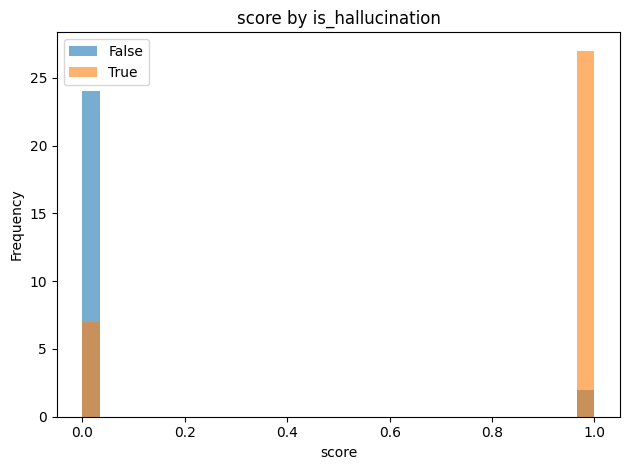

In [16]:
import matplotlib.pyplot as plt

def plot_split_histogram(df, value_col: str, bool_col: str, bins: int = 30, alpha: float = 0.6):
    fig, ax = plt.subplots()

    for group, data in df.groupby(bool_col)[value_col]:
        ax.hist(data, bins=bins, alpha=alpha, label=str(group))

    ax.set_xlabel(value_col)
    ax.set_ylabel("Frequency")
    ax.set_title(f"{value_col} by {bool_col}")
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_split_histogram(evaluations_df, value_col="score", bool_col="is_hallucination")

In [18]:
#evaluations_df["score_mean"] = evaluations_df.groupby(filter_columns)['score'].transform('mean')
#evaluations_df["score_median"] = evaluations_df.groupby(filter_columns)['score'].transform('median')

#if normalise_threshold:
#    #evaluation_df["threshold"] = evaluation_df["score_mean"]
#    evaluations_df["threshold"] = evaluations_df["score_median"]
#    evaluations_df["passed"] = np.where(evaluations_df["score"] > evaluations_df["threshold"], True, False)

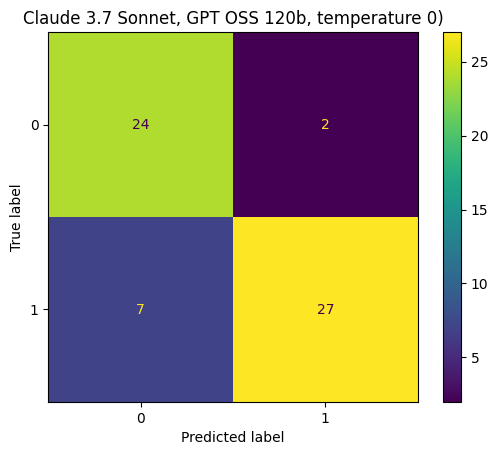

precision: 0.93, recall: 0.79, f1: 0.86

{'f1': 0.8571428571428571,
 'model_name': 'Claude 3.7 Sonnet, GPT OSS 120b',
 'precision': 0.9310344827586207,
 'recall': 0.7941176470588235,
 'score_diff': np.float64(0.7171945701357465),
 'score_hallucination': np.float64(0.7941176470588235),
 'score_mean': np.float64(0.4833333333333334),
 'score_median': np.float64(0.5),
 'score_not_hallucination': np.float64(0.07692307692307693),
 'temperature': '0'}


In [19]:
def get_results(df):
    results = {}

    results["model_name"] = f"{", ".join(df["model_name"].drop_duplicates().values)}"
    results["temperature"] = f"{str(df["temperature"].drop_duplicates().values[0])}"

    results["score_hallucination"] = df[df["is_hallucination"]]["score"].mean()
    results["score_not_hallucination"] = df[~df["is_hallucination"]]["score"].mean()
    results["score_diff"] = results["score_hallucination"] - results["score_not_hallucination"]
    results["score_mean"] = df["score_mean"].mean()
    results["score_median"] = df["score_median"].mean()
    #results["score_mean"] = (results["score_correct"] + results["score_incorrect"])/2
      
    results["precision"] = metrics.precision_score(df["is_hallucination"], df["passed"], zero_division=np.nan)
    results["recall"] = metrics.recall_score(df["is_hallucination"], df["passed"])
    results["f1"] = metrics.f1_score(df["is_hallucination"], df["passed"])
    confusion_matrix = metrics.confusion_matrix(df["is_hallucination"], df["passed"])
    
    cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])
    cm_display.plot()
    #plt.title(f"{results["method"]} ({results["model_name"]})")
    plt.title(f"{results["model_name"]}, temperature {results["temperature"]})")
    plt.show()
    print(f"precision: {results["precision"]:.2}, recall: {results["recall"]:.2}, f1: {results["f1"]:.2}\n")
    
    return results

evaluations_df["score_mean"] = evaluations_df.groupby('model_name')['score'].transform('mean')
evaluations_df["score_median"] = evaluations_df.groupby('model_name')['score'].transform('median')

results = get_results(evaluations_df)
pprint.pprint(results)

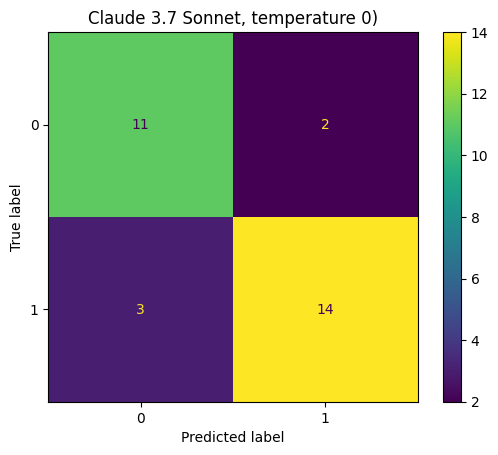

precision: 0.88, recall: 0.82, f1: 0.85



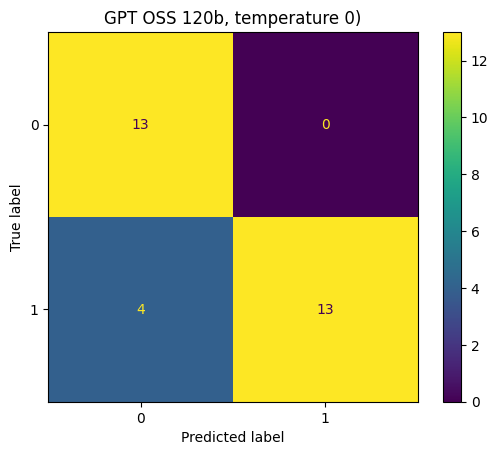

precision: 1.0, recall: 0.76, f1: 0.87



,model_name,temperature,score_hallucination,score_not_hallucination,score_diff,score_mean,score_median,precision,recall,f1
0,Claude 3.7 Sonnet,0,0.823529,0.153846,0.669683,0.533333,1.0,0.875,0.823529,0.848485
1,GPT OSS 120b,0,0.764706,0.000000,0.764706,0.433333,0.0,1.000,0.764706,0.866667


In [20]:
results_models = []
for row in evaluations_df[['model_name']].drop_duplicates().to_dict('records'):
    filter_df = evaluations_df.copy()
    filter_df = filter_df[filter_df['model_name'] == row['model_name']]

    if len(filter_df) > 0:
        results = get_results(filter_df)
        results_models.append(results)

results_df = pd.DataFrame(results_models)
results_df.to_csv('output/results.csv', index=False)
results_df

,temperature,score_hallucination,score_not_hallucination,score_diff,score_mean,score_median,precision,recall,f1
model_name,,,,,,,,,
Claude 3.7 Sonnet,0,0.823529,0.153846,0.669683,0.533333,1.0,0.875,0.823529,0.848485
GPT OSS 120b,0,0.764706,0.000000,0.764706,0.433333,0.0,1.000,0.764706,0.866667


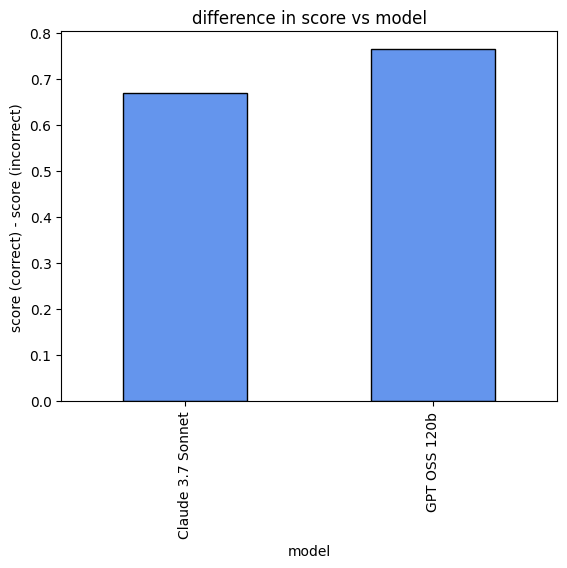

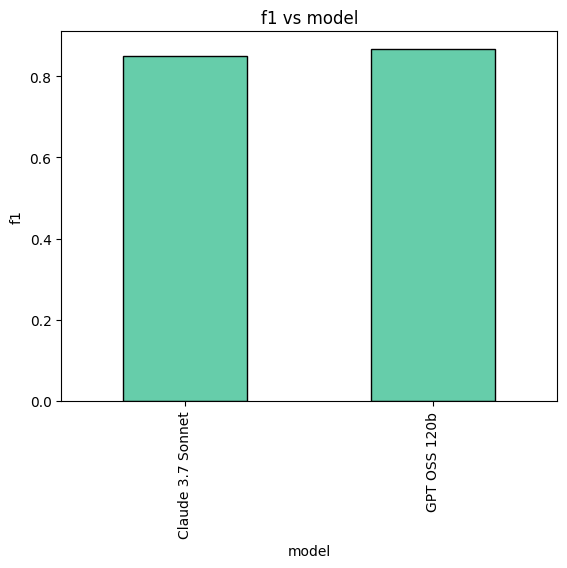

In [21]:
plot_df = results_df.set_index("model_name")

if len(plot_df) > 0:
    display(plot_df)
    plot_df["score_diff"].plot(kind="bar", xlabel="model",  ylabel="score (correct) - score (incorrect)", title=f"difference in score vs model", color="cornflowerblue", edgecolor="black")
    plt.show()
    plot_df["f1"].plot(kind="bar", xlabel="model", ylabel="f1", title=f"f1 vs model", color="mediumaquamarine", edgecolor="black")
    plt.show()